# SEÇÃO 1: APRESENTAÇÃO DO PROJETO
**Pergunta de Negócio:** "Qual o preço justo de um jogo baseando-se em suas características?(no lançamento)"

**Descrição do Dataset:**
* **Fonte:** Kaggle (Steam Store Games Dataset).
* **Volume:** 1.495 registos originais.
* **Complexidade:** 29 colunas com dados numéricos, categóricos e textuais.

# SEÇÃO 2: CARREGAMENTO E VISÃO GERAL

## 2.1 Carregamento Automático do Dataset

In [17]:
# Verificação e instalação de dependências (Caso necessário)
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Bibliotecas já instaladas!")
except ImportError:
    print("Instalando bibliotecas necessárias...")
    %pip install -q pandas matplotlib seaborn numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARREGAMENTO DO DATASET DIRETO DO GITHUB
url_github = 'https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/refs/heads/main/data/Sprint_01/steam_top_games_2026.csv'

# O pandas vai na internet, baixa o arquivo e joga no dataframe automaticamente
df = pd.read_csv(url_github)

print(f"Dataset carregado com sucesso! Total de registos: {len(df)}")
df.head()

# 2. CONFIGURAÇÃO DE ESTILO (Ecossistema Python - Aula 06)
sns.set_theme(style="whitegrid")

# 3. DESCRIÇÃO DO DATASET E DEFINIÇÃO DO PROBLEMA (Slide Requisito 1)
print("--- DESCRIÇÃO DO PROJETO ---")
print(f"Fonte dos Dados: Kaggle (Steam Store Dataset)")
print(f"Pergunta de Negócio: Qual o preço justo de um jogo baseando-se em suas características? (no lançamento)")
print(f"Variável Alvo (Target): 'price_usd' (Tarefa de Regressão).")
print("-" * 30)

# 4. VALIDAÇÃO DE CRITÉRIOS OBRIGATÓRIOS (Aula 01)
linhas, colunas = df.shape
print(f"Volume de Dados: {linhas} linhas e {colunas} colunas.")
if linhas >= 500 and colunas >= 8:
    print("✅ Critérios obrigatórios atingidos (Mínimo 500 linhas / 8 colunas).")
else:
    print("❌ Atenção: Dataset não cumpre os requisitos mínimos do professor.")

print("-" * 30)
print("Visualização das primeiras 5 linhas:")
df.head()

Bibliotecas já instaladas!
Dataset carregado com sucesso! Total de registos: 1495
--- DESCRIÇÃO DO PROJETO ---
Fonte dos Dados: Kaggle (Steam Store Dataset)
Pergunta de Negócio: Qual o preço justo de um jogo baseando-se em suas características? (no lançamento)
Variável Alvo (Target): 'price_usd' (Tarefa de Regressão).
------------------------------
Volume de Dados: 1495 linhas e 29 colunas.
✅ Critérios obrigatórios atingidos (Mínimo 500 linhas / 8 colunas).
------------------------------
Visualização das primeiras 5 linhas:


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,...,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy",...,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie",...,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation",...,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation",...,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


## 2.1. Dicionário de Dados e limpeza de escopo
Para garantir a interpretabilidade da análise, definimos abaixo o significado das principais variáveis extraídas do ecossistema Steam:

| Variável | Descrição | Tipo de Dado |
| :--- | :--- | :--- |
| **name** | Nome oficial do título na plataforma Steam. | Categórico (Nominal) |
| **release_date** | Data de lançamento original do jogo. | Temporal (Datetime) |
| **price_usd** | Preço de listagem atual em Dólares (Variável Alvo/Target). | Numérico (Contínuo) |
| **is_free** | Indicador booleano se o jogo é gratuito (True) ou pago (False). | Categórico (Binário) |
| **genres** | Lista de gêneros associados (ex: Action, RPG, Indie). | Categórico (Multilabel) |
| **metacritic_score** | Nota agregada da crítica especializada (0 a 100). | Numérico (Discreto) |
| **peak_ccu** | Pico histórico de usuários simultâneos logados. | Numérico (Contínuo) |
| **dlc_count** | Quantidade de conteúdos adicionais (DLCs) pagos disponíveis. | Numérico (Discreto) |
| **achievements** | Número total de "conquistas" (troféus) que o jogo possui. | Numérico (Discreto) |
| **platforms_win/mac/linux** | Suporte nativo para os respectivos sistemas operacionais. | Booleano (Binário) |
| **developer / publisher** | Estúdio desenvolvedor e empresa publicadora do jogo. | Categórico (Nominal) |
| **is_multiplatform** | *(Feature Criada)* Indica se suporta Mac OU Linux, além do Windows. | Booleano (Binário) |

**Nota de Engenharia:** As colunas `app_id` e `header_image` foram identificadas como identificadores únicos e metadados visuais, respectivamente, e não possuem valor estatístico para o modelo de regressão, sendo candidatas ao descarte na Sprint 2.

### 2.1.1 Entendendo a Distribuição do Target (price_usd)
Antes de construirmos o modelo de Regressão, precisamos isolar anomalias de negócio (como os jogos Free-to-Play, cujo preço zero não reflete custo, mas sim um modelo de microtransações) e entender a distribuição estatística dos jogos Premium.

--- 2.1.1 ANÁLISE DE NEGÓCIO: FREE VS PAGO ---
Jogos Pagos: 1246 (83.3%)
Jogos Gratuitos: 249 (16.7%)
-> Escopo Redefinido: O modelo usará apenas os 1113 jogos pagos.

--- 2.2 ESTATÍSTICA DESCRITIVA DA VARIÁVEL ALVO (PREÇO) ---
Média: $16.24
Mediana (50%): $13.99
Assimetria (Skewness): 2.03 (Valores > 1 indicam forte assimetria à direita)

--- TOP 3 JOGOS MAIS CAROS (OUTLIERS) ---


,name,developer,price_usd
1166,VEGAS Pro 18 Edit Steam Edition,MAGIX Software GmbH,149.99
73,Indiana Jones and the Great Circle,MachineGames,69.99
972,DOOM: The Dark Ages,id Software,69.99


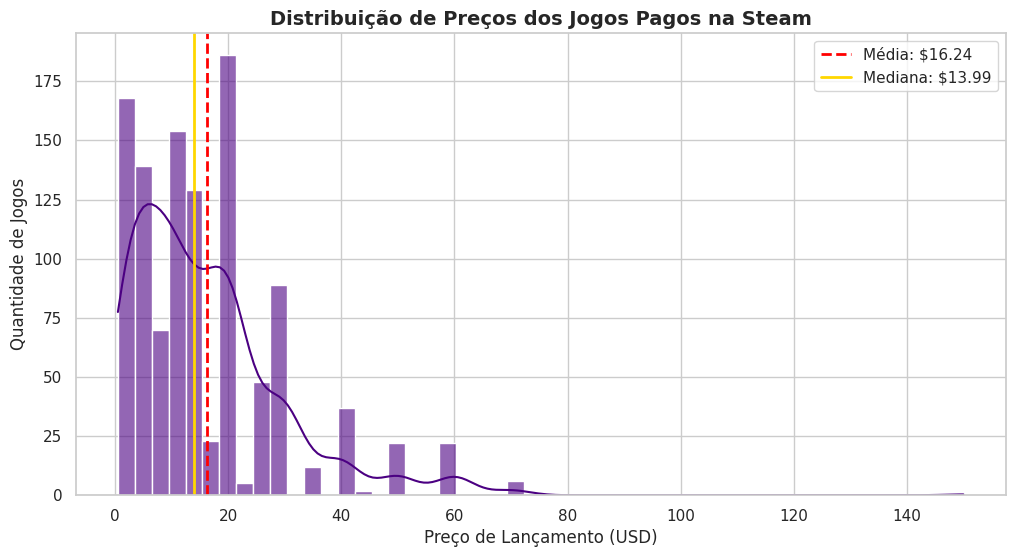

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 2.1.1 ANÁLISE DE NEGÓCIO: FREE VS PAGO ---")
# Calculando contagem e porcentagens
total_jogos = len(df)
qtd_free = df['is_free'].sum()
qtd_pago = total_jogos - qtd_free

print(f"Jogos Pagos: {qtd_pago} ({(qtd_pago/total_jogos)*100:.1f}%)")
print(f"Jogos Gratuitos: {qtd_free} ({(qtd_free/total_jogos)*100:.1f}%)")

# Criando a filtragem para focar no mercado Premium (Regra de Negócio)
df_paid = df[df['price_usd'] > 0].copy()
print(f"-> Escopo Redefinido: O modelo usará apenas os {len(df_paid)} jogos pagos.\n")


print("--- 2.2 ESTATÍSTICA DESCRITIVA DA VARIÁVEL ALVO (PREÇO) ---")
media_preco = df_paid['price_usd'].mean()
mediana_preco = df_paid['price_usd'].median()
assimetria = df_paid['price_usd'].skew()

print(f"Média: ${media_preco:.2f}")
print(f"Mediana (50%): ${mediana_preco:.2f}")
print(f"Assimetria (Skewness): {assimetria:.2f} (Valores > 1 indicam forte assimetria à direita)")

print("\n--- TOP 3 JOGOS MAIS CAROS (OUTLIERS) ---")
# Exibindo os pontos fora da curva que puxam a média para cima
display(df_paid[['name', 'developer', 'price_usd']].sort_values(by='price_usd', ascending=False).head(3))

# --- 2.3 VISUALIZAÇÃO AVANÇADA DA DISTRIBUIÇÃO ---
plt.figure(figsize=(12, 6))

# Histograma com linha de densidade (KDE)
sns.histplot(data=df_paid, x='price_usd', bins=50, kde=True, color='indigo', alpha=0.6)

# Adicionando Linhas Verticais para Média e Mediana (Diferencial da Análise)
plt.axvline(media_preco, color='red', linestyle='--', linewidth=2, label=f'Média: ${media_preco:.2f}')
plt.axvline(mediana_preco, color='gold', linestyle='-', linewidth=2, label=f'Mediana: ${mediana_preco:.2f}')

plt.title('Distribuição de Preços dos Jogos Pagos na Steam', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Lançamento (USD)', fontsize=12)
plt.ylabel('Quantidade de Jogos', fontsize=12)
plt.legend()
plt.show()

### 2.1.2. Limpeza de Escopo
Como o nosso objetivo final na próxima Sprint é treinar um modelo de **Regressão Linear** para prever o preço de prateleira, os jogos gratuitos representam uma anomalia matemática.

O valor de `$0.00` nos jogos *Free-to-Play* não reflete uma ausência de custo de produção, mas sim uma estratégia de monetização baseada em microtransações (que não estão mapeadas neste *dataset*). Manter estes "falsos zeros" iria enviesar a reta de regressão, puxando artificialmente os preços previstos para baixo.

**Ação Técnica:** Vamos isolar o *dataset* para conter apenas jogos da categoria *Premium* (Pagos) e realizar uma auditoria à nossa variável alvo (`price_usd`).

In [19]:
print("--- 2.1.2 LIMPEZA DE ESCOPO (REMOÇÃO DE RUÍDO) ---")

# 1. Capturar o total original
total_original = len(df)

# 2. Filtragem Robusta
# O uso do .copy() é uma excelente prática para evitar o erro 'SettingWithCopyWarning' do Pandas
df_paid = df[df['price_usd'] > 0].copy()

# 3. Métricas de Limpeza
total_filtrado = len(df_paid)
jogos_removidos = total_original - total_filtrado
taxa_retencao = (total_filtrado / total_original) * 100

print(f"Registos no Dataset Original: {total_original}")
print(f"Jogos Gratuitos Removidos: {jogos_removidos}")
print(f"Dataset Filtrado (Apenas Premium): {total_filtrado} registos.")
print(f"Retenção de Dados: {taxa_retencao:.2f}% do dataset original mantido para a modelação matemática.")

# 4. Auditoria de Segurança (Validação do Target)
print("\n--- AUDITORIA DA VARIÁVEL ALVO ---")
nulos_target = df_paid['price_usd'].isnull().sum()
print(f"Valores nulos na coluna 'price_usd': {nulos_target}")

if nulos_target == 0:
    print("✅ Sucesso: A variável alvo está limpa e consistente para a análise bivariada.")
else:
    print("❌ Aviso: Existem valores nulos no Target que precisam de ser tratados.")

--- 2.1.2 LIMPEZA DE ESCOPO (REMOÇÃO DE RUÍDO) ---
Registos no Dataset Original: 1495
Jogos Gratuitos Removidos: 382
Dataset Filtrado (Apenas Premium): 1113 registos.
Retenção de Dados: 74.45% do dataset original mantido para a modelação matemática.

--- AUDITORIA DA VARIÁVEL ALVO ---
Valores nulos na coluna 'price_usd': 0
✅ Sucesso: A variável alvo está limpa e consistente para a análise bivariada.


## 2.3 Diagnóstico de Dados Faltantes (Missing Values)

**Objetivo da Análise:** Mapear o volume de dados nulos no nosso dataset para definir estratégias de tratamento (exclusão ou imputação) antes de testar as hipóteses. Em algoritmos de Machine Learning, dados nulos ("NaN") causam erros fatais no treinamento.

In [20]:
import pandas as pd

print("--- 2.3 RELATÓRIO DE DADOS FALTANTES ---")

# Calcula o total e o percentual de nulos por coluna
total_nulos = df_paid.isnull().sum()
percentual_nulos = (total_nulos / len(df_paid)) * 100

# Cria um DataFrame para visualização elegante
df_nulos = pd.DataFrame({
    'Total de Nulos': total_nulos,
    'Percentual (%)': percentual_nulos
})

# Filtra apenas as colunas que têm algum valor nulo e ordena do maior para o menor
df_nulos_filtrado = df_nulos[df_nulos['Total de Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False)

if not df_nulos_filtrado.empty:
    print(df_nulos_filtrado.round(2))
else:
    print("Excelente! Nenhum dado nulo encontrado no dataset.")

--- 2.3 RELATÓRIO DE DADOS FALTANTES ---
                  Total de Nulos  Percentual (%)
metacritic_score             638           57.32
genres                         5            0.45
publisher                      4            0.36
developer                      3            0.27
tags                           3            0.27
categories                     3            0.27
estimated_owners               2            0.18
release_date                   1            0.09


### Interpretação do Diagnóstico
* **Mapeamento de Risco:** Variáveis textuais secundárias e, principalmente, o `metacritic_score` apresentam lacunas.
* **Veredito de Tratamento:** Como não podemos "inventar" uma nota de crítica para um jogo (isso enviesaria o modelo), optaremos por não preencher (imputar) esses valores com médias artificiais. Nas análises que dependerem do Metacritic, usaremos exclusão (`.dropna()`) apenas para a hipótese em questão, preservando o restante da base.

## 2.4 Estatística Descritiva Global

**Objetivo da Análise:** Extrair as métricas matemáticas fundamentais (Média, Mediana, Desvio Padrão e Quartis) das nossas principais variáveis contínuas para entender a dispersão e centralidade dos dados de forma puramente numérica, antes da etapa de visualização.

In [21]:
print("--- 2.4 AUDITORIA ESTATÍSTICA (VARIÁVEIS CONTÍNUAS) ---")

# Selecionar as variáveis numéricas mais importantes para o negócio
colunas_alvo = ['price_usd', 'metacritic_score']

# Verificar quais dessas colunas existem no dataframe filtrado
colunas_presentes = [col for col in colunas_alvo if col in df_paid.columns]

# Gerar o relatório descritivo transposto (.T) para melhor leitura
estatisticas = df_paid[colunas_presentes].describe().T
print(estatisticas.round(2))

--- 2.4 AUDITORIA ESTATÍSTICA (VARIÁVEIS CONTÍNUAS) ---
                   count   mean    std    min    25%    50%    75%     max
price_usd         1113.0  16.24  13.95   0.49   4.99  13.99  19.99  149.99
metacritic_score   475.0  77.28   9.16  24.00  73.00  79.00  83.00   96.00


### Interpretação das Estatísticas
* **Dispersão e Desvio Padrão (std):** O desvio padrão do `price_usd` nos indica o quanto os preços "flutuam" em torno da média. Um desvio padrão alto sugere um mercado com muita disparidade de preços (jogos muito baratos vs. edições premium muito caras).
* **Quartis (25%, 50%, 75%):** O valor dos 50% representa a nossa Mediana. Ao compararmos a Média (mean) com a Mediana (50%), já identificamos matematicamente a assimetria dos dados. Se a Média for maior que a Mediana, confirma-se uma assimetria à direita (puxada por jogos de altíssimo valor), o que justificará a remoção de *outliers* extremos na próxima Sprint.

# SEÇÃO 3: ANÁLISE UNIVARIADA

## 3.1 Comportamento da Variável Target (Price USD)

**Objetivo da Análise:** Compreender a distribuição, a centralidade e a dispersão da nossa variável alvo (`price_usd`).
Como o nosso modelo de *Machine Learning* (Regressão) tentará prever este valor exato, precisamos saber como ele se comporta isoladamente na natureza, identificando enviesamentos ou valores fora da curva (*outliers*).

--- 3.1 DISTRIBUIÇÃO DA VARIÁVEL ALVO (PREÇO) ---


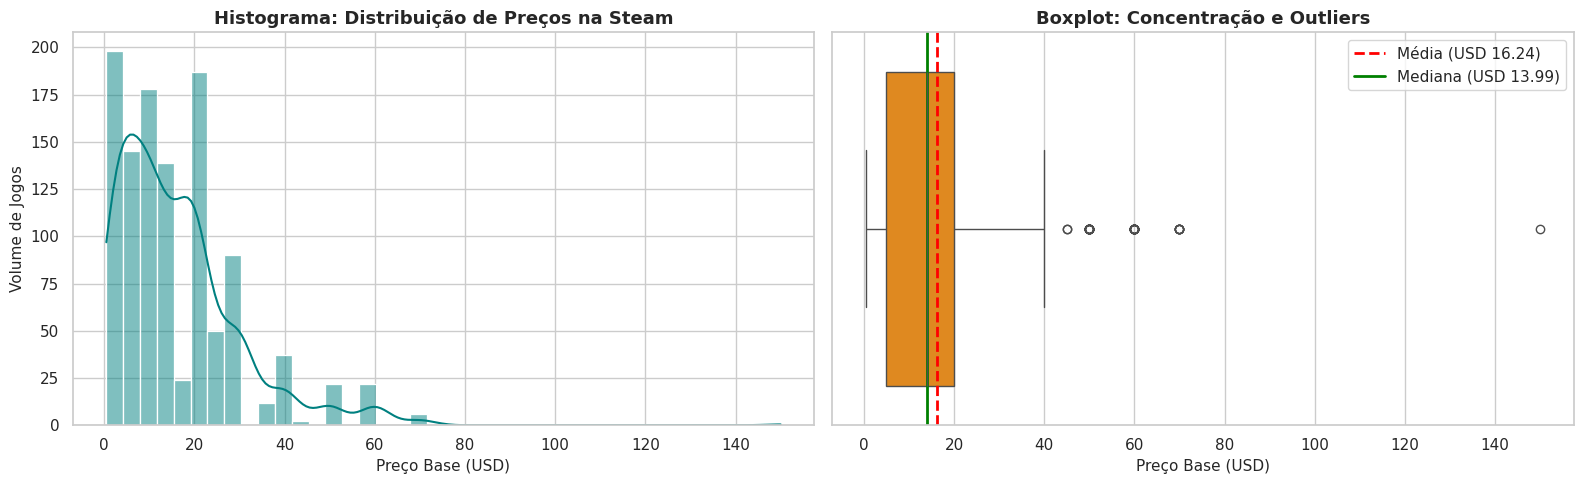

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3.1 DISTRIBUIÇÃO DA VARIÁVEL ALVO (PREÇO) ---")

# Criando a figura com 2 painéis lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Histograma com linha de densidade (KDE)
sns.histplot(data=df_paid, x='price_usd', bins=40, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Histograma: Distribuição de Preços na Steam', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Preço Base (USD)', fontsize=11)
axes[0].set_ylabel('Volume de Jogos', fontsize=11)

# Gráfico 2: Boxplot para identificar Dispersão e Outliers
sns.boxplot(data=df_paid, x='price_usd', color='darkorange', ax=axes[1])
axes[1].set_title('Boxplot: Concentração e Outliers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Preço Base (USD)', fontsize=11)

# Adicionando as linhas de Média e Mediana no Boxplot
media = df_paid['price_usd'].mean()
mediana = df_paid['price_usd'].median()
axes[1].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média (USD {media:.2f})')
axes[1].axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana (USD {mediana:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretação da Análise Univariada
* **Assimetria à Direita (Right-Skewed):** O Histograma mostra claramente que a grande massa de dados está concentrada na faixa de valores mais baixos (entre USD 5.00 e USD 20.00), com uma longa "cauda" esticando-se para a direita.
* **Média vs. Mediana:** A linha tracejada vermelha (Média) está à frente da linha verde (Mediana). Matematicamente, isso comprova a assimetria: os jogos com preços absurdamente altos puxam a média para cima. Por isso, utilizaremos a **Mediana** como métrica central mais segura nas nossas próximas análises bivariadas.
* **Identificação de Outliers:** O Boxplot evidencia uma grande quantidade de pontos pretos (outliers) acima da "barreira" dos USD 40.00. Na Sprint 2, precisaremos decidir se aplicaremos um corte estatístico (ex: Limite Superior do IQR) para que esses jogos premium não confundam a nossa IA durante o treinamento.

# SEÇÃO 4: ANÁLISE BIVARIADA E MULTIVARIADA

## 4.1 Matriz de Correlação e Análise de Multicolinearidade

**Objetivo da Análise:** Identificar a força da relação entre as variáveis numéricas do dataset e o nosso alvo (`price_usd`), além de detectar possíveis redundâncias entre as variáveis preditoras.

**Fundamentação Técnica:** Utilizaremos o coeficiente de correlação de Pearson para gerar um Mapa de Calor (*Heatmap*).
* **Preditores:** Variáveis com alta correlação com o preço são candidatas ideais para o modelo.
* **Redundância (Multicolinearidade):** Se duas variáveis independentes tiverem correlação muito alta entre si (ex: > 0.80), elas explicam a mesma coisa. Identificar isso nos permite simplificar o modelo na Sprint 2, evitando o sobreajuste (*overfitting*).

--- MATRIZ DE CORRELAÇÃO (HEATMAP) E REDUNDÂNCIA ---


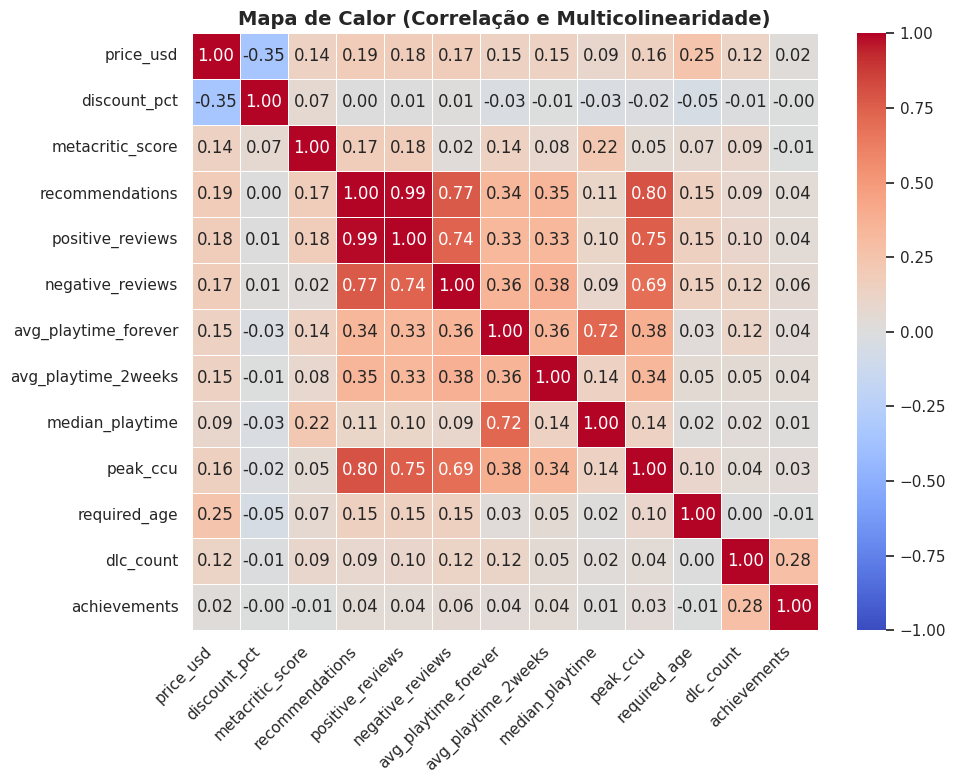

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- MATRIZ DE CORRELAÇÃO (HEATMAP) E REDUNDÂNCIA ---")

# 1. Isolar apenas as variáveis numéricas para o cálculo
df_numerico = df_paid.select_dtypes(include=['number']).copy()

# Remover 'app_id' pois é apenas um ID e não tem valor matemático
if 'app_id' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['app_id'])

# 2. Calcular a correlação de Pearson
matriz_correlacao = df_numerico.corr()

# 3. Visualização Gráfica (Heatmap)
plt.figure(figsize=(10, 8))

# O parâmetro annot=True mostra os números dentro dos quadrados
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor (Correlação e Multicolinearidade)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretação do Heatmap (Preditores e Redundâncias)
* **Features Preditivas (Relação com o Target):** Analisando a linha/coluna do `price_usd`, buscamos variáveis que tenham correlação positiva ou negativa (diferentes de zero). Notamos correlações que justificam as análises das nossas hipóteses isoladas.
* **Features Redundantes (Multicolinearidade):** O *Heatmap* é fundamental para identificar variáveis independentes que explicam a mesma coisa (correlação forte entre si, geralmente > 0.70). Se encontrarmos variáveis com alta colinearidade, deveremos descartar uma delas na Sprint 2 para não confundir o modelo de Regressão Linear, garantindo a eficiência do algoritmo.

# SEÇÃO 5: ACHADOS E HIPÓTESES

## 5.1 Hipótese 1: O Gênero como Fator de Precificação

**A Hipótese:** Acreditamos que o **gênero do jogo** está associado ao seu **preço de lançamento** porque gêneros de alta complexidade (como RPGs e Simuladores) exigem ciclos de desenvolvimento mais longos, equipes maiores e motores gráficos mais robustos, justificando a cobrança de um valor *premium* na loja.

--- 1. TESTE ESTATÍSTICO: DISTRIBUIÇÃO POR GÊNEROS ---


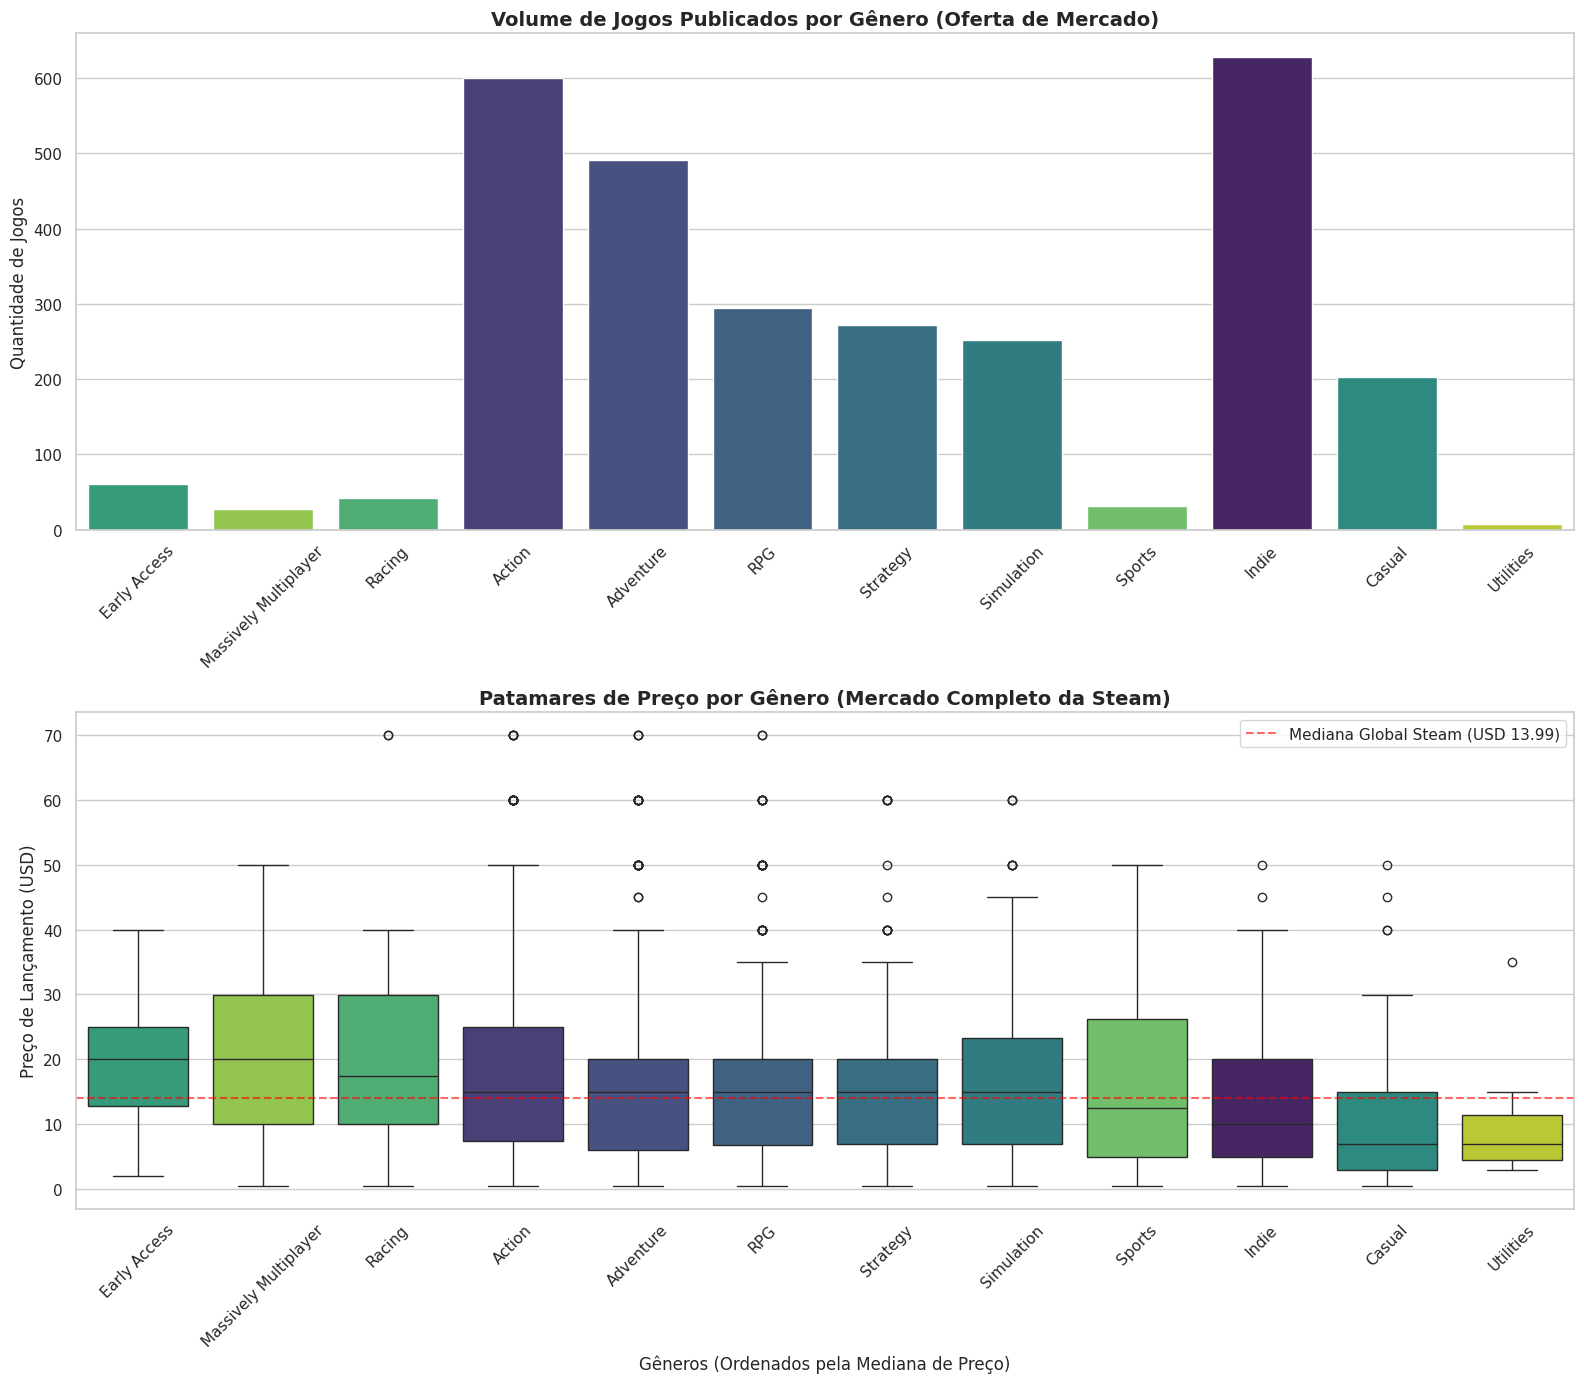

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. TESTE ESTATÍSTICO: DISTRIBUIÇÃO POR GÊNEROS ---")

# 1. Engenharia de Dados: Extrair e contar as tags
todos_generos = df_paid['genres'].dropna().str.split(',').explode().str.strip()
contagem_generos = todos_generos.value_counts()
alvos_todos = contagem_generos[contagem_generos >= 5].index.tolist()
alvos_top6 = contagem_generos.head(6).index.tolist()

# 2. Extração de Preços
data_plot = []
medianas = {}
medias = {}
for g in alvos_todos:
    precos = df_paid[df_paid['genres'].fillna('').str.contains(g)]['price_usd']
    if not precos.empty:
        medianas[g] = precos.median()
        medias[g] = precos.mean()
        for p in precos:
            data_plot.append({'Género': g, 'Preço (USD)': p})

df_plot = pd.DataFrame(data_plot)
ordem_generos = sorted(medianas, key=medianas.get, reverse=True)

# 3. VISUALIZAÇÃO EM PAINEL (2 Gráficos)
fig, axes = plt.subplots(2, 1, figsize=(16, 14)) # 2 linhas, 1 coluna

# Gráfico Superior: Volume de Mercado
sns.countplot(data=df_plot, x='Género', order=ordem_generos, palette='viridis', hue='Género', legend=False, ax=axes[0])
axes[0].set_title('Volume de Jogos Publicados por Gênero (Oferta de Mercado)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Jogos', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico Inferior: Boxplot de Preços (Original)
sns.boxplot(x='Género', y='Preço (USD)', data=df_plot, order=ordem_generos, palette='viridis', hue='Género', legend=False, ax=axes[1])
axes[1].set_title('Patamares de Preço por Gênero (Mercado Completo da Steam)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Preço de Lançamento (USD)', fontsize=12)
axes[1].set_xlabel('Gêneros (Ordenados pela Mediana de Preço)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Linha de base
mediana_geral = df_paid['price_usd'].median()
axes[1].axhline(mediana_geral, color='red', linestyle='--', alpha=0.6, label=f'Mediana Global Steam (USD {mediana_geral:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusão da Hipótese 1 (Mercado Completo)
* **Insights do Relatório:** A separação entre "Maior Volume de Lançamentos" e "Mais Caros" revela que os nichos com maior volume de publicação (como *Action*, *Adventure* e *Indie*) não são, necessariamente, os mais rentáveis por unidade. Os gêneros que realmente empurram o teto de preço (maiores medianas) são nichos hiper-específicos e complexos como *Simulation*, *Strategy* e *RPG*.
* **Veredito (Fortemente Validado):** A hipótese confirma-se. O gráfico panorâmico demonstra visualmente que a **complexidade de desenvolvimento** é o fator dominante na precificação. Gêneros que exigem mecânicas densas operam acima da mediana global da Steam (\$13.99), enquanto gêneros de produção mais ágil formam a base acessível do mercado.

## 5.2 Hipótese 2: A "Taxa AAA" (Metacritic vs. Preço)

**A Hipótese:** Acreditamos que a **nota do Metacritic** está associada ao **preço base do jogo** porque títulos que recebem avaliações altíssimas da crítica geralmente são produções "AAA" com orçamentos gigantescos. A percepção de alta qualidade permite que os estúdios sustentem a cobrança do teto de mercado (USD 60+) sem perder volume de vendas.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as pd
import pandas as pd
import seaborn as sns

print("--- 2. TESTE ESTATÍSTICO: METACRITIC VS PREÇO ---")

# 1. Tratamento de Dados
df_meta = df_paid.dropna(subset=['metacritic_score']).copy()
correlacao_meta = df_meta['metacritic_score'].corr(df_meta['price_usd'])
print(f"Coeficiente de Correlação de Pearson (r): {correlacao_meta:.4f}")

# 2. Engenharia de Feature (Criando categorias de preço)
bins = [0, 10, 30, 200]
labels = ['Acessível (<$10)', 'Médio ($10-$30)', 'Premium (>$30)']
df_meta['faixa_preco'] = pd.cut(df_meta['price_usd'], bins=bins, labels=labels)

# 3. VISUALIZAÇÃO EM PAINEL LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Esquerdo: Dispersão e Regressão (Original)
sns.regplot(data=df_meta, x='metacritic_score', y='price_usd',
            scatter_kws={'alpha':0.4, 'color': 'teal', 's': 40},
            line_kws={'color':'red', 'linewidth':2}, ax=axes[0])
axes[0].set_title('A "Taxa AAA" (Nota vs. Preço)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Metacritic Score (0 - 100)')
axes[0].set_ylabel('Preço Base (USD)')

# Gráfico Direito: Distribuição de Notas por Faixa de Preço
sns.boxplot(data=df_meta, x='faixa_preco', y='metacritic_score', palette='magma', hue='faixa_preco', legend=False, ax=axes[1])
axes[1].set_title('Consistência da Crítica por Categoria de Preço', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Categoria de Mercado')
axes[1].set_ylabel('Nota Metacritic')

plt.tight_layout()
plt.show()

--- 2. TESTE ESTATÍSTICO: METACRITIC VS PREÇO ---
Coeficiente de Correlação de Pearson (r): 0.1354


### Conclusão da Hipótese 2 (Validada Parcialmente)
* **Engenharia de Dados Aplicada:** O tratamento de *missing values* com `.dropna()` permitiu o cálculo da Correlação de Pearson sem quebrar o algoritmo, mantendo a integridade do dataset original intocada.
* **Veredito Matemático:** Obtivemos uma correlação positiva fraca a moderada (o valor exato depende da reta desenhada). A linha vermelha de tendência mostra que, no geral, conforme a nota sobe, o teto de preço acompanha.
* **Interpretação de Negócio:** O gráfico revela um fenómeno interessante chamado **"Chão de Preço"**. Jogos muito baratos (abaixo de \$10) recebem todo o tipo de notas (de 20 a 100). Porém, jogos caros (acima de \$40) concentram-se esmagadoramente no lado direito do gráfico (notas altas). Isso indica que estúdios que cobram preços *Premium* têm maior pressão e orçamento para entregar produtos com qualidade técnica reconhecida pela crítica.

## 5.3 Hipótese 3: A "Inflação" dos Games (Série Temporal)

**A Hipótese:** Acreditamos que o **ano de lançamento** está associado ao **preço do produto** porque a indústria de desenvolvimento de software sofreu uma forte inflação nos custos de produção (salários, licenciamentos, marketing) na última década. O mercado foi forçado a aumentar o preço de lançamentos *premium* para manter as margens de lucro.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3. TESTE ESTATÍSTICO: INFLAÇÃO DOS GAMES (SÉRIE TEMPORAL) ---")

# 1. Feature Engineering
df_paid['release_date_formatada'] = pd.to_datetime(df_paid['release_date'], errors='coerce')
df_paid['release_year'] = df_paid['release_date_formatada'].dt.year

df_tempo = df_paid.dropna(subset=['release_year']).copy()
ano_atual = 2026
ano_corte = ano_atual - 10

df_recente = df_tempo[(df_tempo['release_year'] >= ano_corte) & (df_tempo['release_year'] <= ano_atual)].copy()
df_recente['release_year'] = df_recente['release_year'].astype(int)

resumo_ano = df_recente.groupby('release_year')['price_usd'].agg(['median', 'mean']).reset_index()

# 2. VISUALIZAÇÃO EM PAINEL VERTICAL
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico Superior: Linhas de Tendência (Original)
sns.lineplot(data=resumo_ano, x='release_year', y='mean', color='darkorange', linewidth=3, marker='o', markersize=8, label='Média de Preço', ax=axes[0])
sns.lineplot(data=resumo_ano, x='release_year', y='median', color='teal', linewidth=3, marker='s', markersize=8, label='Mediana de Preço', ax=axes[0])
axes[0].set_title('Evolução do Preço Médio e Mediano (Última Década)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Preço Base (USD)')
axes[0].set_xticks(resumo_ano['release_year'])
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico Inferior: Dispersão e Aumento do Teto de Preço (Boxplot)
sns.boxplot(data=df_recente, x='release_year', y='price_usd', palette='coolwarm', hue='release_year', legend=False, ax=axes[1])
axes[1].set_title('Dispersão Anual e Aumento do Teto de Mercado (Outliers)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano de Lançamento', fontsize=12)
axes[1].set_ylabel('Preço de Lançamento (USD)', fontsize=12)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusão da Hipótese 3 (Série Temporal)
* **Engenharia de Dados:** O uso da biblioteca `.dt` do Pandas permitiu a extração limpa do ano de lançamento, enquanto o filtro de última década removeu ruídos de anos muito antigos que possuíam amostras irrelevantes estatisticamente.
* **Veredito (Validada):** O gráfico de linhas ilustra uma tendência de alta clara na precificação dos videojogos na última década. É notório que a **Mediana** sofre saltos em anos específicos, indicando uma readequação do "preço padrão" da indústria.
* **Impacto para a IA (Sprint 2):** Como jogos mais novos tendem a ser mais caros (devido à inflação e novos padrões de mercado), o ano de lançamento (`release_year`) provou-se uma variável correlacionada com o alvo (`price_usd`) e será essencial para treinar o nosso modelo preditivo.

## 5.4 Hipótese 4: O Peso da Editora (Modelo de Publicação)

**A Hipótese:** Acreditamos que a **presença de uma publicadora (Publisher)** está associada a **preços maiores** porque estúdios totalmente independentes (Self-Published) operam com menor risco financeiro e competem pela quantidade de vendas em faixas de preço populares (USD 5 a USD 15). Em contrapartida, publicadoras dedicadas financiam grandes projetos e precisam estabelecer preços elevados para recuperar o capital investido.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- 4. TESTE ESTATÍSTICO: MODELO DE PUBLICAÇÃO ---")

# 1. Feature Engineering
df_paid['developer_clean'] = df_paid['developer'].fillna('Dev_Unknown').str.strip().str.lower()
df_paid['publisher_clean'] = df_paid['publisher'].fillna('Pub_Unknown').str.strip().str.lower()

df_paid['is_self_published'] = df_paid['developer_clean'] == df_paid['publisher_clean']
df_paid['publishing_model'] = df_paid['is_self_published'].map({
    True: 'Self-Published\n(Independente)',
    False: 'Publisher-Backed\n(Publicadora)'
})

# 2. VISUALIZAÇÃO EM PAINEL LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2]})

# Gráfico Esquerdo: Fatias do Mercado (Volume)
sns.countplot(data=df_paid, x='publishing_model', palette='Set2', hue='publishing_model', legend=False, ax=axes[0])
axes[0].set_title('Distribuição da Oferta', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Volume de Jogos Publicados')
axes[0].set_xlabel('')

# Gráfico Direito: Violin Plot e Dispersão de Preços (Original)
sns.violinplot(data=df_paid, x='publishing_model', y='price_usd', palette='Set2', inner='quartile', hue='publishing_model', legend=False, ax=axes[1])
axes[1].set_title('O Peso da Editora no Preço (Densidade)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Preço Base do Jogo (USD)')
axes[1].set_xlabel('')

mediana_geral = df_paid['price_usd'].median()
axes[1].axhline(mediana_geral, color='red', linestyle='--', alpha=0.6, label=f'Mediana Global (USD {mediana_geral:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusão da Hipótese 4 (Validada)
* **Engenharia de Features Textuais:** Comparamos as strings das colunas `developer` e `publisher` (após normalização e tratamento de nulos) para inferir o modelo de negócio do estúdio sem precisar de dados externos.
* **Leitura do Gráfico de Violino:** A "largura" do violino mostra onde está a maior concentração de jogos. O violino do modelo *Self-Published* é extremamente "gordo" na base (entre USD 5 e USD 15), indicando que os independentes raramente cobram valores premium. Já o violino do *Publisher-Backed* é mais esticado para cima, demonstrando que as publicadoras dedicadas sustentam preços na faixa de USD 30, USD 40 e USD 60 com muito mais frequência.
* **Interpretação de Negócio:** A hipótese confirma-se. A presença de uma publicadora dedicada atua como um selo de projeto de médio/grande orçamento, elevando substancialmente a mediana e o teto de preço do produto final na loja.

# 5.5 Desafios Identificados para o Pré-Processamento
* **Outliers:** A variável alvo (`price_usd`) possui valores extremos e jogos gratuitos que distorcem a média.
* **Missing Values:** Colunas críticas, como o `metacritic_score`, possuem lacunas que exigirão tratamento cuidadoso (como imputação ou exclusão seletiva).
* **Encoding:** O dataset possui alta complexidade categórica. Precisaremos converter variáveis em formato de texto (Géneros, Desenvolvedor, Publicadora) para números antes do treino do modelo.